In [3]:
import pretty_midi
import os
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import datetime
from torch.utils.data import random_split

In [4]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2,3"
print(f"GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

GPUs: 3
Device 0: NVIDIA GeForce GTX 1080
Device 1: NVIDIA GeForce GTX 1080
Device 2: NVIDIA GeForce GTX 1080


In [5]:
test_run = True

In [6]:
def check_midi_stats(file_path):
    try:
        pm = pretty_midi.PrettyMIDI(file_path)
        return {
            "resolution": pm.resolution,
            "instruments": len(pm.instruments),
            "duration": pm.get_end_time(),
            "programs": [i.program for i in pm.instruments]
        }
    except:
        return None

# Test one file
maestro_sample = "datasets/midi/maestro/maestro-v3.0.0/2011/MIDI-Unprocessed_01_R1_2011_MID--AUDIO_R1-D1_02_Track02_wav.midi"
lakh_sample = "datasets/midi/lakh/AC_DC/TNT.mid"
lakh2_sample = "datasets/midi/lakh/Britney_Spears/Oops..._I_Did_It_Again.1.mid"

print(f"Maestro Stats: {check_midi_stats(maestro_sample)}")
print(f"Lakh Stats: {check_midi_stats(lakh_sample)}")
print(f"Lakh Stats: {check_midi_stats(lakh2_sample)}")

Maestro Stats: {'resolution': 384, 'instruments': 1, 'duration': 153.49088541666666, 'programs': [0]}
Lakh Stats: {'resolution': 192, 'instruments': 8, 'duration': 202.7378925, 'programs': [0, 29, 30, 29, 52, 80, 35, 29]}
Lakh Stats: {'resolution': 240, 'instruments': 17, 'duration': 210.38924519166665, 'programs': [35, 37, 17, 67, 55, 29, 1, 74, 11, 0, 62, 119, 53, 48, 50, 46, 66]}


# PIANO only
## MIDI to binary

0-7 Pianos
create a list of all the notes with their delta time played

In [7]:
def midi_to_advanced_sequence(file_path):
    try:
        pm = pretty_midi.PrettyMIDI(file_path)
        # Merge piano channels into one
        piano_notes = []
        for inst in pm.instruments:
            if inst.program <= 7 and not inst.is_drum:
                piano_notes.extend(inst.notes)
        
        if not piano_notes: return None
        
        # Sort by starting time
        piano_notes.sort(key=lambda x: x.start)
        
        advanced_sequence = []
        prev_start = piano_notes[0].start
        
        for note in piano_notes:
            delta_time = note.start - prev_start
            duration = note.end - note.start
            
            # save: [Pitch, Delta_Time, Duration, Velocity]
            advanced_sequence.append([
                note.pitch, 
                delta_time, 
                duration, 
                note.velocity
            ])
            prev_start = note.start
            
        return advanced_sequence
    except Exception as e:
        return None

adv_seq = midi_to_advanced_sequence(maestro_sample)
print(adv_seq[:2])

[[50, 0.0, 0.5794270833333333, 84], [38, 0.005208333333333259, 0.62109375, 74]]


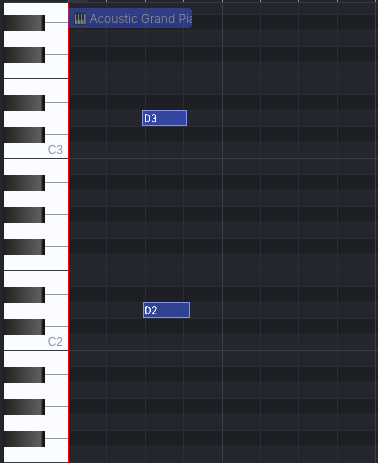

We check if they are matching <br>
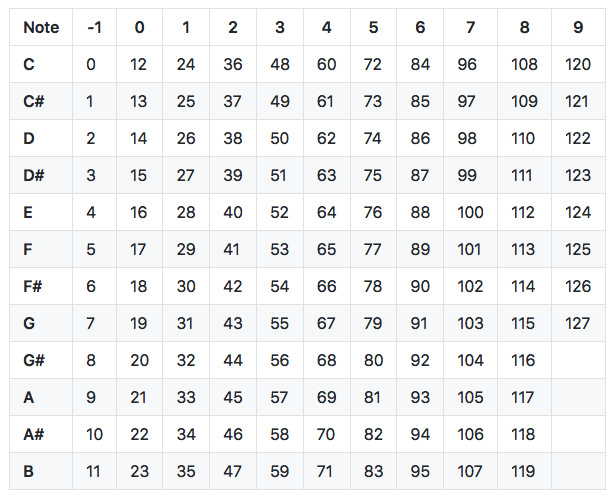 <br>
50 - D3 <br>
38 - D2 <br>
Velocity is also alright.

In [8]:
## PITCH ONLY
def midi_to_simple_sequence(file_path):
    try:
        pm = pretty_midi.PrettyMIDI(file_path)
        # only first instrument
        piano = [inst for inst in pm.instruments if inst.program <= 7 and not inst.is_drum]
        
        if not piano:
            return None
        
        # Sort notes by starting time
        notes = sorted(piano[0].notes, key=lambda x: x.start)
        
        # First just pitch extraction
        pitch_sequence = [note.pitch for note in notes]
        return pitch_sequence
    except Exception as e:
        print(f"Fehler bei {file_path}: {e}")
        return None


sample_seq = midi_to_simple_sequence(maestro_sample)
print(f"First 10 notes: {sample_seq[:10]}")

First 10 notes: [50, 38, 62, 64, 66, 67, 69, 66, 69, 74]


In [8]:
def midi_to_merged_piano_sequence(file_path):
    try:
        pm = pretty_midi.PrettyMIDI(file_path)
        all_piano_notes = []
        
        for inst in pm.instruments:
            if 0 <= inst.program <= 7 and not inst.is_drum:
                all_piano_notes.extend(inst.notes)
        
        if not all_piano_notes:
            return None
        
        all_piano_notes.sort(key=lambda x: (x.start, x.pitch))
        
        return [note.pitch for note in all_piano_notes]
    except:
        return None

In [10]:
MAX_DELTA = 1.5
MAX_DUR = 4.0

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
class MusicLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=256, num_layers=2):
        super(MusicLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.intermediate = nn.Linear(hidden_size, 128)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(128, 4)
        
    def forward(self, x):
        # Forward pass through LSTM
        out, _ = self.lstm(x)
        
        # Take the output of the last time step
        out = out[:, -1, :]
        
        # Apply the intermediate linear layer and Sigmoid activation
        out = self.sigmoid(self.intermediate(out))
        
        # Final output layer
        return self.fc(out)

In [13]:
class MusicGRU(nn.Module):
    def __init__(self, input_size=4, hidden_size=512):
        super(MusicGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=3, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 4)
        
    def forward(self, x):
        out, _ = self.gru(x)
        return torch.sigmoid(self.fc(out[:, -1, :]))

In [14]:
class MusicTransformer(nn.Module):
    def __init__(self, input_size=4, d_model=128, nhead=8, num_layers=4, window_size=64):
        super(MusicTransformer, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        
        self.pos_embedding = nn.Parameter(torch.zeros(1, window_size, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=512,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc_hidden = nn.Linear(d_model, 64)
        self.sigmoid = nn.Sigmoid()
        self.fc_out = nn.Linear(64, 4)

    def forward(self, x):
        
        x = self.embedding(x) + self.pos_embedding
        
        out = self.transformer(x)
        
        # Take the last time step
        out = out[:, -1, :]
        # Applying Sigmoid activation
        out = self.sigmoid(self.fc_hidden(out))
        return self.fc_out(out)

In [15]:
def load_all_midi_data(root_dir, max_files=10000):
    root = Path(root_dir)
    # Searches for midi
    files = list(root.rglob("*.mid")) + list(root.rglob("*.midi"))
    
    all_notes = []
    print(f"Found {root_dir}... {len(files)} files.")
    
    for f in files[:max_files]:
        seq = midi_to_advanced_sequence(str(f))
        if seq:
            all_notes.extend(seq)
            
    return np.array(all_notes)

In [16]:
class MusicDataset(Dataset):
    def __init__(self, data, window_size=50):
        self.window_size = window_size
        # Normalization
        self.data = data.copy()
        self.data[:, 0] /= 127.0  # Pitch
        self.data[:, 3] /= 127.0  # Velocity
        self.data[:, 1] = np.clip(self.data[:, 1], 0, MAX_DELTA) / MAX_DELTA
        self.data[:, 2] = np.clip(self.data[:, 2], 0, MAX_DUR) / MAX_DUR
        
        self.data = torch.tensor(self.data, dtype=torch.float32)

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size]
        return x, y

# execution
if test_run:
    max_files = 50
else:
    max_files = 2000
    
raw_data = load_all_midi_data("datasets/midi/maestro", max_files)
dataset = MusicDataset(raw_data, window_size=64)
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

Suche in datasets/midi/maestro... 1276 Dateien gefunden.


In [17]:
# random split
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# two seperate loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=128, 
    shuffle=True, 
    num_workers=4,   
    pin_memory=True  
)

val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

In [18]:
def train_model(model, train_loader, val_loader, model_name, epochs=20, lr=0.001):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # TensorBoard Setup
    current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    writer = SummaryWriter(f"runs/{model_name}_{current_time}")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    train_hist, val_hist = [], []
    best_val_loss = float('inf')

    print(f"\n--- Starting training for: {model_name} ---")
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        total_train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        
        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_v, y_v in val_loader:
                x_v, y_v = x_v.to(device), y_v.to(device)
                v_out = model(x_v)
                v_loss = criterion(v_out, y_v)
                total_val_loss += v_loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        
        # Save data
        train_hist.append(avg_train_loss)
        val_hist.append(avg_val_loss)
        
        # TensorBoard Logging
        writer.add_scalars(f'Loss/{model_name}', {
            'Train': avg_train_loss,
            'Validation': avg_val_loss
        }, epoch)
        
        # Checkpoint: Save modell if validation loss goes down
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"best_{model_name}.pth")
            checkpoint_msg = " (Best Model saved!)"
        else:
            checkpoint_msg = ""

        # Print for every epoch
        print(f"Epoche [{epoch+1:02d}/{epochs}] - "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Val Loss: {avg_val_loss:.6f}{checkpoint_msg}")

    writer.close()
    return train_hist, val_hist

In [19]:
def plot_results(histories, names):
    """
    histories: list of tuples [(train_h, val_h), ...]
    names: list of model names
    """
    plt.figure(figsize=(14, 8))
    colors = ['blue', 'green', 'red']
    
    for i, (hists, name) in enumerate(zip(histories, names)):
        train_h, val_h = hists
        # Training line
        plt.plot(train_h, label=f'{name} (Train)', color=colors[i], linewidth=2)
        # Validation line
        plt.plot(val_h, label=f'{name} (Val)', color=colors[i], linestyle='--', alpha=0.7)
    
    plt.yscale('log')
    plt.title("Training- vs. Validation-Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss (Log Scale)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [20]:
def prepare_model(model_class, **kwargs):
    model = model_class(**kwargs).to(device)
    if torch.cuda.device_count() > 1:
        # Batches on all 4 graphic cards
        model = nn.DataParallel(model)
    return model

model_lstm = prepare_model(MusicLSTM)
model_gru = prepare_model(MusicGRU)
model_transformer = prepare_model(MusicTransformer)
# window_size = 64

epochs = 10
print("Training LSTM")
res_lstm = train_model(model_lstm, train_loader, val_loader, "LSTM", epochs)
print("Training GRU")
#es_gru = train_model(model_gru, train_loader, val_loader, "GRU", epochs)
print("Training Transformer")
res_trans = train_model(model_transformer, train_loader, val_loader, "Transformer", epochs, lr=0.0005)

# Plot
plot_results([res_lstm, res_gru, res_trans], ["LSTM", "GRU", "Transformer"])

Training LSTM

--- Starte Training für: LSTM ---
Epoche [01/10] - Train Loss: 1.130142 | Val Loss: 1.120564 (Bestes Modell gespeichert!)
Epoche [02/10] - Train Loss: 1.118801 | Val Loss: 1.117872 (Bestes Modell gespeichert!)
Epoche [03/10] - Train Loss: 1.116502 | Val Loss: 1.115253 (Bestes Modell gespeichert!)
Epoche [04/10] - Train Loss: 1.114255 | Val Loss: 1.114246 (Bestes Modell gespeichert!)
Epoche [05/10] - Train Loss: 1.112054 | Val Loss: 1.111511 (Bestes Modell gespeichert!)
Epoche [06/10] - Train Loss: 1.110603 | Val Loss: 1.110572 (Bestes Modell gespeichert!)
Epoche [07/10] - Train Loss: 1.109275 | Val Loss: 1.109639 (Bestes Modell gespeichert!)
Epoche [08/10] - Train Loss: 1.108217 | Val Loss: 1.109097 (Bestes Modell gespeichert!)
Epoche [09/10] - Train Loss: 1.107046 | Val Loss: 1.109020 (Bestes Modell gespeichert!)
Epoche [10/10] - Train Loss: 1.105886 | Val Loss: 1.107947 (Bestes Modell gespeichert!)
Training GRU
Training Transformer

--- Starte Training für: Transformer

/home/nour_mbb/dl_mbb/lib/python3.8/site-packages/torch/nn/modules/linear.py:117: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return F.linear(input, self.weight, self.bias)


Epoche [01/10] - Train Loss: 1.125128 | Val Loss: 1.121500 (Bestes Modell gespeichert!)
Epoche [02/10] - Train Loss: 1.117692 | Val Loss: 1.116233 (Bestes Modell gespeichert!)
Epoche [03/10] - Train Loss: 1.115382 | Val Loss: 1.115156 (Bestes Modell gespeichert!)
Epoche [04/10] - Train Loss: 1.113951 | Val Loss: 1.113402 (Bestes Modell gespeichert!)
Epoche [05/10] - Train Loss: 1.112866 | Val Loss: 1.114224
Epoche [06/10] - Train Loss: 1.112008 | Val Loss: 1.112314 (Bestes Modell gespeichert!)
Epoche [07/10] - Train Loss: 1.111039 | Val Loss: 1.110868 (Bestes Modell gespeichert!)
Epoche [08/10] - Train Loss: 1.110420 | Val Loss: 1.110620 (Bestes Modell gespeichert!)
Epoche [09/10] - Train Loss: 1.109706 | Val Loss: 1.110286 (Bestes Modell gespeichert!)
Epoche [10/10] - Train Loss: 1.109283 | Val Loss: 1.109416 (Bestes Modell gespeichert!)


In [24]:
def generate_training_variance_midi(model, dataset, model_name, device, gen_length=500, temperature=1.0):
    """
    Generates MIDI with variance directly from training.
    """
    model.eval()
    output_folder = "output_midi"
    os.makedirs(output_folder, exist_ok=True)
    
    # 1. Get seed from the dataset
    start_idx = np.random.randint(0, len(dataset) - 1)
    input_seq, _ = dataset[start_idx]
    input_seq = input_seq.unsqueeze(0).to(device) # Batch dimension
    
    generated_notes = []

    print(f"--- Generating variance MIDI for {model_name} ---")
    
    with torch.no_grad():
        for i in range(gen_length):
            # Prediction
            output = model(input_seq)
            
            # Variance logic: Adding controlled noise
            # Temperature > 1.0 makes it "bolder", < 1.0 "more conservative"
            noise = torch.randn_like(output) * (0.05 * temperature)
            output = torch.clamp(output + noise, 0, 1)
            
            next_note = output.cpu().numpy()[0]
            generated_notes.append(next_note)
            
            # Sliding window update
            new_input = output.unsqueeze(1)
            input_seq = torch.cat((input_seq[:, 1:, :], new_input), dim=1)

    # 2. MIDI conversion
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    curr_t = 0
    
    for n in generated_notes:
        pitch = int(n[0] * 127)
        step = max(0, n[1] * MAX_DELTA)  # Time scaling
        dur = max(0.1, n[2] * MAX_DUR)   # Duration
        vel = int(n[3] * 127)
        
        if pitch > 0 and pitch < 128:
            start = curr_t + step
            piano.notes.append(pretty_midi.Note(velocity=vel, pitch=pitch, start=start, end=start+dur))
            curr_t = start
            
    pm.instruments.append(piano)
    
    # Save under the desired name
    save_path = os.path.join(output_folder, f"variance_midi_{model_name}.mid")
    pm.write(save_path)
    print(f"✅ File saved: {save_path}")

In [26]:
models_to_run = [
    (model_lstm, "LSTM"),
    (model_gru, "GRU"),
    (model_transformer, "Transformer")
]

for m_obj, m_name in models_to_run:
    # Check if the model is wrapped in DataParallel
    actual_model = m_obj.module if isinstance(m_obj, torch.nn.DataParallel) else m_obj
    
    generate_training_variance_midi(
        model=actual_model,
        dataset=val_dataset, # Uses your already loaded Val-Dataset
        model_name=m_name,
        device=device,
        temperature=0.4 # Slightly higher value to reduce the risk of loops
    )

--- Generiere Varianz-MIDI für LSTM ---
✅ Datei gespeichert: output_midi/variance_midi_LSTM.mid
--- Generiere Varianz-MIDI für Transformer ---
✅ Datei gespeichert: output_midi/variance_midi_Transformer.mid
